# Experiment 3 — Hard vs Soft (Gaussian) Matching

**Goal:** Compare nearest-neighbour (hard) ICP against Gaussian-weighted (soft) ICP with sigma annealing on the `clustered` cloud style.

1. Per-iteration convergence curves for a single run (residual, rotation error, translation error).
2. Convergence time and amount of steps

In [3]:
import sys
sys.path.insert(0, '../src')

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

from icp import ICP, GaussianMatcher, SigmaAnnealingCallback
from matcher import NearestNeighborMatcher
from synthetic import SyntheticExperiment
from visualization import ErrorMetricsVisualizer, TimeVisualizer

plt.style.use('seaborn-v0_8-whitegrid')

N_SEEDS    = 30
MAX_ITER   = 400
TOL        = 1e-3
GEN_KWARGS = dict(n=2000, noise_std=3.0, t_scale=8.0, style='clustered')

# Gaussian matcher / annealing hyperparameters
SIGMA_INIT  = 25.0
SIGMA_FINAL = 1.0
K_NEIGHBORS = 20

matcher = GaussianMatcher(sigma=SIGMA_INIT, k=K_NEIGHBORS)
annealer = SigmaAnnealingCallback(SIGMA_INIT, SIGMA_FINAL, MAX_ITER)
softICP = ICP(matcher=matcher, max_iter=MAX_ITER, tol=TOL, callbacks=[annealer])    # Soft ICP (Gaussian with annealing)
hardICP = ICP(matcher=NearestNeighborMatcher(), max_iter=MAX_ITER, tol=TOL)         # Hard ICP (nearest-neighbour)

## 1. Compare error metrics convergence

Both matchers run on the same experiment on several seeds. The per-iteration curves show how fast each one descends and whether they reach the correct solution.

In [ ]:
results_hard = []
results_soft = []
experiments = []
for seed in tqdm(range(N_SEEDS), desc=f"Solving {N_SEEDS} seeds"):
    exp = SyntheticExperiment.generate(seed=seed, **GEN_KWARGS)
    result_hard = hardICP.fit(exp.P, exp.Q)
    result_soft = softICP.fit(exp.P, exp.Q)
    results_hard.append(result_hard)
    results_soft.append(result_soft)
    experiments.append(exp)

In [ ]:
ErrorMetricsVisualizer.plot_convergence(
    results_per_method=[results_soft, results_hard],
    experiments_per_method=[experiments, experiments],
    method_labels=["Soft ICP", "Hard ICP"],
    x_label='Iteration',
)

plt.suptitle('Convergence curves — seed=42, clustered')
plt.tight_layout()
plt.savefig('../results/3_hard_vs_soft_matching_error_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Runtime distribution across seeds

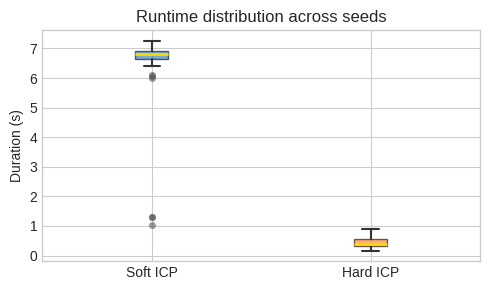

In [6]:
durations_hard = np.array([r.duration_s for r in results_hard])
durations_soft = np.array([r.duration_s for r in results_soft])

fig, ax = plt.subplots(figsize=(5, 3))
TimeVisualizer.plot_duration_distribution(
    ax,
    durations_per_method=[durations_soft, durations_hard],
    method_labels=["Soft ICP", "Hard ICP"],
)
plt.tight_layout()
plt.savefig('../results/3_hard_vs_soft_matching_duration_distribution.png', dpi=150, bbox_inches='tight')
plt.show()